# Double Spring Pendulum

Rebuilt from `legacy/Double Spring Pendulum.ipynb` through `lagrangian.py`.
Two masses on springs in series, generalized coordinates
`(theta1, theta2, r1, r2)`. The legacy notebook ran this with gravity
turned off (`g=0`) just to watch the springs bounce -- but with no gravity
the angular coordinates have no restoring force at all (nothing breaks the
rotational symmetry), so there's no well-defined "hanging" equilibrium to
linearize around. Gravity is kept on (`g=9.81`) here instead, which gives
a proper equilibrium and makes all 4 normal modes meaningful; the
zero-gravity bouncing-springs behavior is still just a parameter change
away if wanted.

In [1]:
import os
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import lagrangian as lg

os.makedirs('media', exist_ok=True)

In [2]:
t, g, m1, m2, L1, L2, k1, k2 = sp.symbols('t g m1 m2 L1 L2 k1 k2')
the1 = sp.Function('the1')(t)
the2 = sp.Function('the2')(t)
r1 = sp.Function('r1')(t)
r2 = sp.Function('r2')(t)

x1 = r1 * sp.sin(the1)
y1 = -r1 * sp.cos(the1)
x2 = x1 + r2 * sp.sin(the2)
y2 = y1 - r2 * sp.cos(the2)

T = (0.5 * m1 * (sp.diff(x1, t)**2 + sp.diff(y1, t)**2)
     + 0.5 * m2 * (sp.diff(x2, t)**2 + sp.diff(y2, t)**2))
U = (m1 * g * y1 + k1 * (r1 - L1)**2 / 2
     + m2 * g * y2 + k2 * (sp.sqrt((x1 - x2)**2 + (y1 - y2)**2) - L2)**2 / 2)
L = T - U
coords = [the1, the2, r1, r2]

sols, coords_d, coords_dd = lg.euler_lagrange(L, coords, t)
dSdt = lg.build_ode_system(sols, coords, coords_d, t, (g, m1, m2, L1, L2, k1, k2))
energy = lg.energy_fn(T, U, coords, coords_d, (g, m1, m2, L1, L2, k1, k2))

## Equilibrium and energy conservation

At the hanging equilibrium (`theta1=theta2=0`), the radial stretches follow
from a simple tension balance: the lower spring supports only mass 2's
weight, the upper spring supports both.

r1_eq = 1.8409, r2_eq = 1.2803


Energy relative drift: 8.89e-08
PASS: energy conserved.


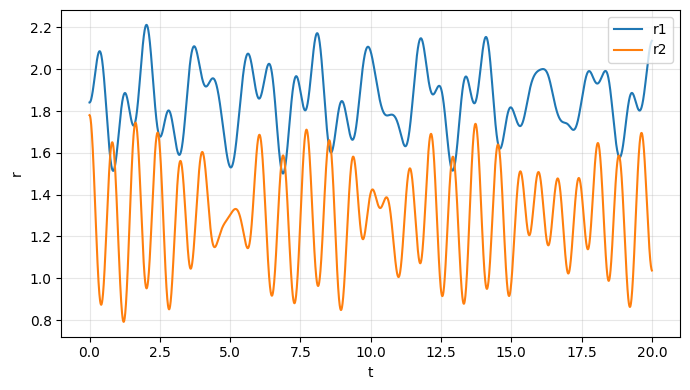

In [3]:
params = (9.81, 2.0, 1.0, 1.0, 1.0, 35.0, 35.0)  # g, m1, m2, L1, L2, k1, k2
pnames = [g, m1, m2, L1, L2, k1, k2]

r2_eq_expr = L2 + m2 * g / k2
r1_eq_expr = L1 + (m1 + m2) * g / k1
r1_eq = float(r1_eq_expr.subs(dict(zip(pnames, params))))
r2_eq = float(r2_eq_expr.subs(dict(zip(pnames, params))))
print(f'r1_eq = {r1_eq:.4f}, r2_eq = {r2_eq:.4f}')

N = 4000
t_arr = np.linspace(0, 20, N)
sol = lg.integrate(dSdt, [0, 0.3, 0.1, 0.2, r1_eq, 0, r2_eq + 0.5, 0], t_arr, params)
the1_t, w1_t, the2_t, w2_t, r1_t, v1_t, r2_t, v2_t = sol.T

E = np.array([energy(the1_t[i], the2_t[i], r1_t[i], r2_t[i],
                      w1_t[i], w2_t[i], v1_t[i], v2_t[i], *params) for i in range(N)])
drift = E.max() - E.min()
print(f'Energy relative drift: {drift/abs(E.mean()):.2e}')
assert drift / abs(E.mean()) < 1e-4, f'energy drift too large: {drift/abs(E.mean()):.2e}'
print('PASS: energy conserved.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_arr, r1_t, label='r1')
ax.plot(t_arr, r2_t, label='r2')
ax.set_xlabel('t'); ax.set_ylabel('r'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/double_spring_pendulum_radii.png', dpi=150, bbox_inches='tight')
plt.show()

## Small-oscillation frequencies vs. `linearize()`

In [4]:
M, K, _ = lg.linearize(L, coords, t, equilibrium={the1: 0, the2: 0, r1: r1_eq, r2: r2_eq})
pvals = dict(zip(pnames, params))
freqs = lg.normal_mode_frequencies(M, K, pvals)
print('linearize() normal-mode frequencies:', freqs)

t_small = np.linspace(0, 150, 30000)
sol_small = lg.integrate(dSdt, [0.01, 0, -0.008, 0, r1_eq + 0.01, 0, r2_eq - 0.008, 0], t_small, params)
dt = t_small[1] - t_small[0]
fr = 2 * np.pi * np.fft.rfftfreq(len(t_small), d=dt)

# A generic small perturbation excites all 4 modes at once, and combination
# tones from the (weak, but nonzero at this amplitude) nonlinearity can
# outrank a true mode's peak height in any single coordinate -- so instead
# of asking "are the loudest peaks the true modes", ask the more robust
# question "does every predicted mode have a real, resolvable peak
# somewhere", searching across all 4 coordinates' spectra.
specs = [np.abs(np.fft.rfft(sol_small[:, 2*j] - sol_small[:, 2*j].mean())) for j in range(4)]
combined = np.max(specs, axis=0)

matched = []
for target in freqs:
    idx = np.argmin(np.abs(fr - target))
    window = slice(max(0, idx - 15), idx + 15)
    local_peak_freq = fr[window][np.argmax(combined[window])]
    err = abs(local_peak_freq - target) / target
    matched.append(err)
    print(f'target {target:.4f} rad/s -> nearest local spectral peak {local_peak_freq:.4f} rad/s (err {err:.3f})')

assert max(matched) < 0.02, f'some normal mode has no matching spectral peak: errors {matched}'
print('PASS: every linearize() normal mode has a matching peak in the full nonlinear integration.')

linearize() normal-mode frequencies: [1.98481181 3.20175931 3.94304568 7.72973074]


target 1.9848 rad/s -> nearest local spectral peak 1.9687 rad/s (err 0.008)
target 3.2018 rad/s -> nearest local spectral peak 3.1834 rad/s (err 0.006)
target 3.9430 rad/s -> nearest local spectral peak 3.9373 rad/s (err 0.001)
target 7.7297 rad/s -> nearest local spectral peak 7.7071 rad/s (err 0.003)
PASS: every linearize() normal mode has a matching peak in the full nonlinear integration.


## Animation

In [5]:
x1_t = r1_t * np.sin(the1_t)
y1_t = -r1_t * np.cos(the1_t)
x2_t = x1_t + r2_t * np.sin(the2_t)
y2_t = y1_t - r2_t * np.cos(the2_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('k')
ax.set(xlim=(-4, 4), ylim=(-6, 1))
ax.set_xticks([]); ax.set_yticks([])
line, = ax.plot([], [], 'o-', color='white', markersize=8)

def animate(i):
    line.set_data([0, x1_t[i], x2_t[i]], [0, y1_t[i], y2_t[i]])
    return (line,)

ani = animation.FuncAnimation(fig, animate, frames=N, interval=20, blit=True)
ani.save('media/double_spring_pendulum.mp4', writer='ffmpeg', fps=50, dpi=130)
plt.close(fig)
print('saved media/double_spring_pendulum.mp4')

saved media/double_spring_pendulum.mp4
